# Stimulus decodability across sessions (early window, PCA embedding)
Per session x region (all neurons of the region): mean population activity in **[0, +0.1 s]** (stimulus onset -> 100 ms), embedded with PCA, decode **stimulus side (contrast>0)** with cross-validation for increasing #components. Trials with **reaction time < 100 ms are excluded**. A **[-0.1, 0 s] pre-stimulus window** is decoded as a control (should be near chance). Cross-validated decodability is saved per region per session per window and per #components.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os
from collections import defaultdict
from iblatlas.regions import BrainRegions
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid'); plt.rcParams['figure.facecolor'] = 'white' 

In [2]:
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
firing_rates_dir = prefix + 'data/firing_rates/'
trials_path = prefix + '4_mice/all_trials_04-05-2026'
out_path = prefix + 'neural/decoding_stim_window_persession.parquet'

REGION_LEVEL = 'cosmos'    # 'cosmos' | 'beryl'
DROP = ['root', 'void']
EVOKED_WIN = (0.0, 0.1)    # stimulus onset -> 100 ms
CONTROL_WIN = (-0.1, 0.0)  # pre-stimulus control
RT_MIN = 0.1               # exclude trials with reaction time < 100 ms
MAX_COMPONENTS = 30        # decode with 1..this many PCA components
CV_FOLDS = 5
MIN_NEURONS = 10
MIN_TRIALS = 40
SEED = 0

trials_df = pd.read_parquet(trials_path)
choice_by_session = {s: g.set_index('trial_id')['choice'] for s, g in trials_df.groupby('session')}
rt_by_session = {s: g.set_index('trial_id')['reaction'] for s, g in trials_df.groupby('session')}
br = BrainRegions()
print("params set")

params set


## Load window-averaged activity per session (all probes combined)

In [3]:
pkl_files = sorted([f for f in os.listdir(firing_rates_dir) if f.startswith('firing_rate_')])
with open(os.path.join(firing_rates_dir, pkl_files[0]), 'rb') as f:
    s0 = pickle.load(f)
tcols = sorted([c for c in s0.columns if c.startswith('t_')], key=lambda x: float(x.split('_')[1]))
tsec = np.array([float(c.split('_')[1]) for c in tcols])
ev_cols = [c for c, m in zip(tcols, (tsec >= EVOKED_WIN[0]) & (tsec <= EVOKED_WIN[1])) if m]
ct_cols = [c for c, m in zip(tcols, (tsec >= CONTROL_WIN[0]) & (tsec <= CONTROL_WIN[1])) if m]
print(f"evoked bins: {len(ev_cols)}  control bins: {len(ct_cols)}")

sess_ev = defaultdict(list); sess_ct = defaultdict(list); sess_meta = {}
for i, fn in enumerate(pkl_files):
    try:
        with open(os.path.join(firing_rates_dir, fn), 'rb') as f:
            d = pickle.load(f)
        d = d[~d['area'].isin(DROP)]
        if len(d) == 0: continue
        session = d['session'].iloc[0]
        d = d.copy(); d['nuid'] = d['pid'].astype(str) + '__' + d['neuron_id'].astype(str)
        d['ev'] = d[ev_cols].mean(axis=1); d['ct'] = d[ct_cols].mean(axis=1)
        piv_ev = d.pivot_table(index='trial_id', columns='nuid', values='ev')
        piv_ct = d.pivot_table(index='trial_id', columns='nuid', values='ct')
        amap = d.groupby('nuid')['area'].first()
        if REGION_LEVEL == 'cosmos':
            cmap = dict(zip(amap.dropna().unique(), br.acronym2acronym(amap.dropna().unique(), mapping='Cosmos')))
            amap = amap.map(cmap)
        sess_ev[session].append((piv_ev, amap)); sess_ct[session].append((piv_ct, amap))
        if session not in sess_meta:
            trials = piv_ev.index
            cond = d.drop_duplicates('trial_id').set_index('trial_id')['condition'].reindex(trials)
            m = pd.DataFrame(index=trials)
            m['stim'] = cond.str.split('_').str[0].map({'Left': 0, 'Right': 1}).values
            m['contrast'] = cond.str.split('_').str[1].astype(float).values
            m['rt'] = rt_by_session.get(session, pd.Series(dtype=float)).reindex(trials).values
            sess_meta[session] = m
        if (i + 1) % 100 == 0: print(f"  {i+1}/{len(pkl_files)} files...")
    except Exception as e:
        print(f"Error {fn}: {e}")
print(f"Sessions loaded: {len(sess_ev)}")

evoked bins: 6  control bins: 6
  100/380 files...
  200/380 files...
  300/380 files...
Sessions loaded: 244


## Decode (leak-free PCA) and save per region/session/window

In [4]:
def decode_curve(X, y, K, cv, seed=SEED):
    """X: trials x neurons (window-averaged); y: labels. Leak-free (scaler+PCA per train fold).
    Returns (accuracy per k array of length up to K, n_trials used)."""
    m = ~np.isnan(y) & ~np.isnan(X).any(axis=1)
    X, y = X[m], y[m].astype(int)
    n = X.shape[0]
    if n < MIN_TRIALS or len(np.unique(y)) < 2 or min(np.bincount(y)) < cv:
        return None, n
    K = min(K, X.shape[1], n - n // cv - 1)
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=seed)
    per_k = np.full((K, cv), np.nan)
    for fi, (tr, te) in enumerate(skf.split(X, y)):
        sc = StandardScaler().fit(X[tr]); Xtr, Xte = sc.transform(X[tr]), sc.transform(X[te])
        nc = min(K, Xtr.shape[1], Xtr.shape[0] - 1)
        pca = PCA(n_components=nc, random_state=seed).fit(Xtr)
        Ztr, Zte = pca.transform(Xtr), pca.transform(Xte)
        for k in range(1, nc + 1):
            clf = LDA().fit(Ztr[:, :k], y[tr])
            per_k[k - 1, fi] = balanced_accuracy_score(y[te], clf.predict(Zte[:, :k]))
    return np.nanmean(per_k, axis=1), n

records = []
for si, session in enumerate(sess_ev):
    Xev = pd.concat([p for p, _ in sess_ev[session]], axis=1)
    Xct = pd.concat([p for p, _ in sess_ct[session]], axis=1)
    areas = pd.concat([a for _, a in sess_ev[session]]); areas = areas[~areas.index.duplicated()]
    meta = sess_meta[session].reindex(Xev.index)
    stim = meta['stim'].values.astype(float)
    keep = (meta['rt'].values >= RT_MIN) & (meta['contrast'].values > 0)     # RT>=100ms & contrast>0
    y = np.where(keep, stim, np.nan)                                          # invalid trials -> nan (dropped)
    for region in pd.unique(areas.values):
        if region is None or (isinstance(region, float) and np.isnan(region)): continue
        cols = areas.index[areas.values == region]
        if len(cols) < MIN_NEURONS: continue
        for wname, X in [('evoked', Xev), ('control', Xct)]:
            accs, n_used = decode_curve(X[cols].values, y, MAX_COMPONENTS, CV_FOLDS)
            if accs is None: continue
            for k, a in enumerate(accs, start=1):
                if np.isfinite(a):
                    records.append(dict(session=session, region=region, window=wname,
                                        n_neurons=len(cols), n_trials=n_used,
                                        n_components=k, accuracy=float(a)))
    if (si + 1) % 50 == 0: print(f"  {si+1}/{len(sess_ev)} sessions...")

dec = pd.DataFrame(records)
dec.to_parquet(out_path)
print(f"Saved {len(dec)} rows to {out_path}")
print(f"  region-session-window entries: {dec.groupby(['session','region','window']).ngroups}")

  50/244 sessions...
  100/244 sessions...
  150/244 sessions...
  200/244 sessions...
Saved 30374 rows to /home/ines/repositories/representation_learning_variability/paper-individuality/neural/decoding_stim_window_persession.parquet
  region-session-window entries: 1174


## Summary: decodability vs #components, evoked vs control

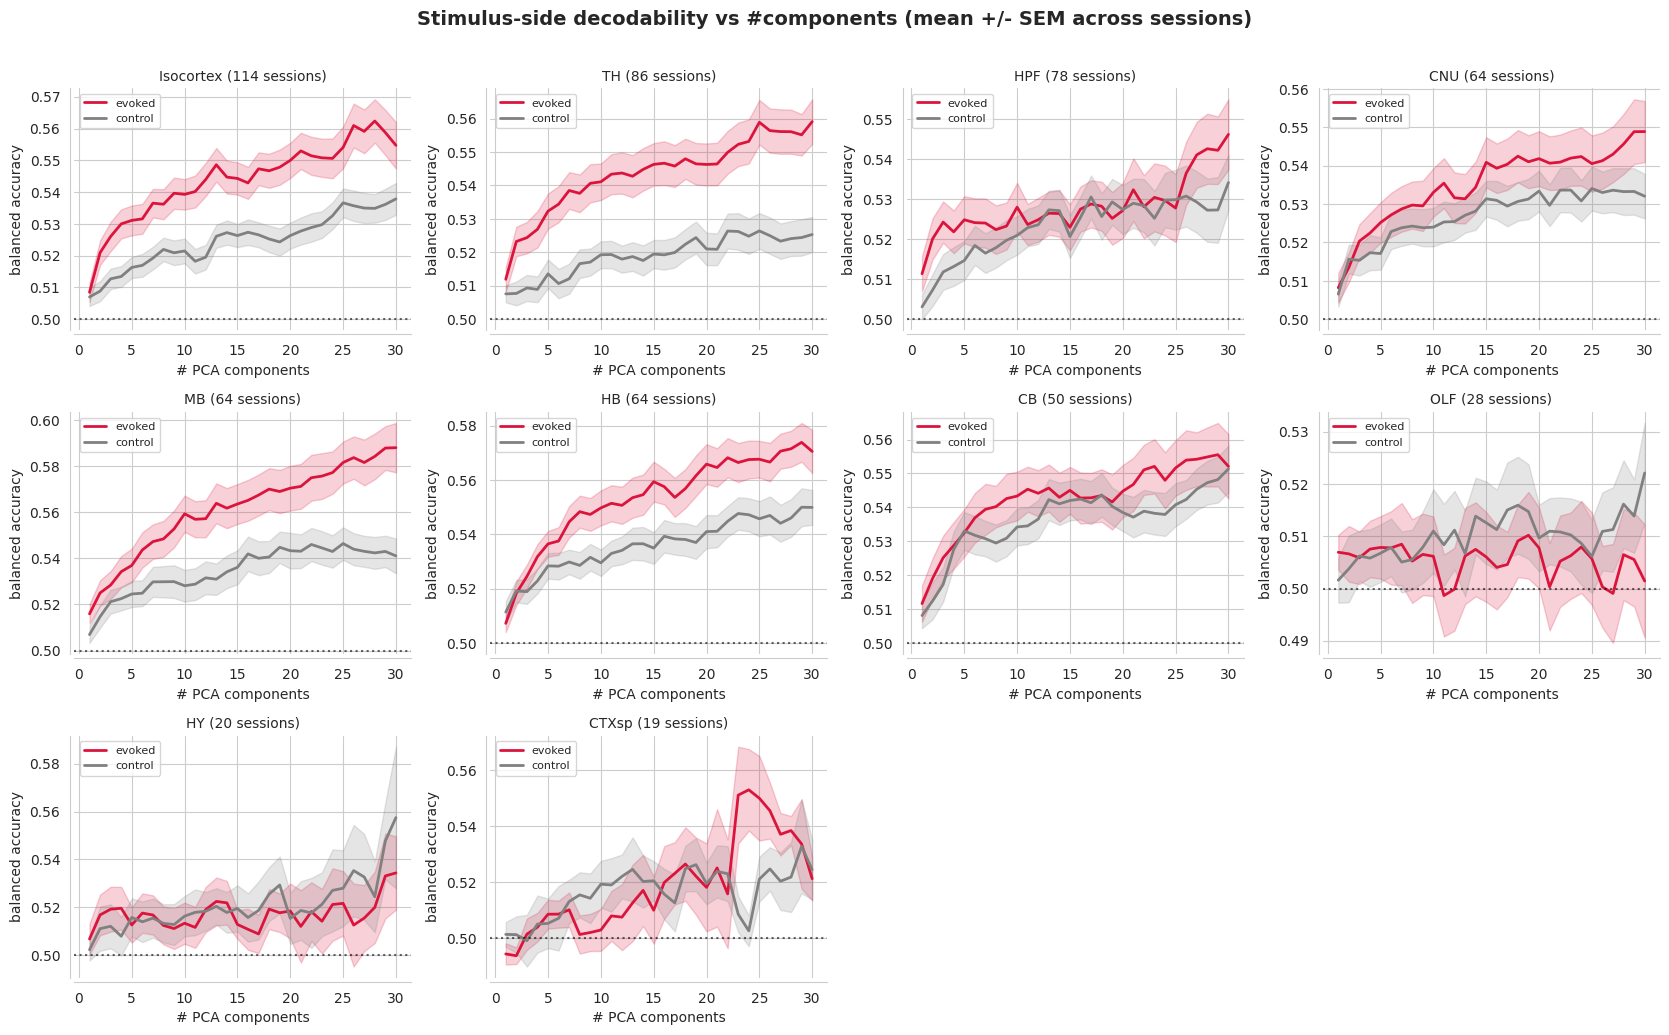

In [5]:
regions = dec.groupby('region')['session'].nunique().sort_values(ascending=False)
regions = regions[regions >= 5].index.tolist()
ncols = 4; nrows = int(np.ceil(len(regions) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.4 * nrows), squeeze=False)
for i, r in enumerate(regions):
    ax = axes[i // ncols][i % ncols]
    for wname, color in [('evoked', 'crimson'), ('control', 'gray')]:
        g = dec[(dec.region == r) & (dec.window == wname)]
        if len(g) == 0: continue
        m = g.groupby('n_components')['accuracy'].agg(['mean', 'sem'])
        ax.plot(m.index, m['mean'], color=color, lw=2, label=wname)
        ax.fill_between(m.index, m['mean'] - m['sem'], m['mean'] + m['sem'], color=color, alpha=0.2)
    ax.axhline(0.5, color='black', ls=':', alpha=0.6)
    ax.set_title(f'{r} ({dec[dec.region==r]["session"].nunique()} sessions)', fontsize=10)
    ax.set_xlabel('# PCA components'); ax.set_ylabel('balanced accuracy'); ax.legend(fontsize=8)
    sns.despine(ax=ax, offset=3)
for i in range(len(regions), nrows * ncols):
    axes[i // ncols][i % ncols].axis('off')
fig.suptitle('Stimulus-side decodability vs #components (mean +/- SEM across sessions)', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Correlate decodability with LDA 1

In [6]:
# ===== Correlate decodability with LDA 1 =====
from scipy.stats import pearsonr, spearmanr
import statsmodels.formula.api as smf

N_EVAL = 10              # #components at which decodability is read
MIN_SESSIONS_CORR = 15
lda = pd.read_pickle(prefix + 'clustering/mouse_LDA_5_bins_cut19-06-2026').rename(columns={0: 'lda_1'})

dd = pd.read_parquet(out_path)
sub = dd[dd['n_components'] == N_EVAL]
piv = sub.pivot_table(index=['session', 'region'], columns='window', values='accuracy').reset_index()
piv = piv.dropna(subset=['evoked', 'control'])
piv['delta'] = piv['evoked'] - piv['control']       # sensory increment (removes prior/drift baseline)
piv = piv.merge(lda[['session', 'lda_1', 'mouse_name']], on='session').dropna(subset=['lda_1'])
well = piv.groupby('region')['session'].nunique(); well = well[well >= MIN_SESSIONS_CORR].index.tolist()
p = piv[piv.region.isin(well)]
print(f"n={len(piv)} session-region entries at k={N_EVAL}; well-sampled regions: {well}")

def pooled(col):
    try:
        r = smf.mixedlm(f"{col} ~ lda_1 + C(region)", p, groups=p['mouse_name'],
                        vc_formula={'session': '0 + C(session)'}).fit(reml=True); m = 'mouse+session'
    except Exception:
        r = smf.mixedlm(f"{col} ~ lda_1 + C(region)", p, groups=p['session']).fit(reml=True); m = 'session'
    return r, m

for col, lab in [('evoked', 'Evoked [0,0.1]'), ('control', 'Control [-0.1,0]'), ('delta', 'Evoked-Control (sensory)')]:
    print(f"\n==== {lab} vs LDA 1 ====")
    for reg, g in p.groupby('region'):
        r, pp = pearsonr(g['lda_1'], g[col]); rho, ppp = spearmanr(g['lda_1'], g[col])
        print(f"  {reg:10s} n={len(g):3d}: r={r:+.2f} p={pp:.3f} | rho={rho:+.2f} p={ppp:.3f}")
    r, m = pooled(col); b, se, pv = r.params['lda_1'], r.bse['lda_1'], r.pvalues['lda_1']
    print(f"  POOLED {col} ~ lda_1 + C(region) + (1|mouse) [{m}]: coef={b:+.4f} z={b/se:+.2f} p={pv:.4f}")

n=587 session-region entries at k=10; well-sampled regions: ['CB', 'CNU', 'CTXsp', 'HB', 'HPF', 'HY', 'Isocortex', 'MB', 'OLF', 'TH']

==== Evoked [0,0.1] vs LDA 1 ====
  CB         n= 50: r=-0.08 p=0.572 | rho=-0.02 p=0.912
  CNU        n= 64: r=-0.20 p=0.105 | rho=-0.27 p=0.032
  CTXsp      n= 19: r=+0.25 p=0.308 | rho=+0.31 p=0.196
  HB         n= 64: r=-0.00 p=0.980 | rho=-0.09 p=0.493
  HPF        n= 78: r=+0.05 p=0.683 | rho=+0.06 p=0.623
  HY         n= 20: r=-0.34 p=0.142 | rho=-0.39 p=0.090
  Isocortex  n=114: r=-0.05 p=0.568 | rho=-0.02 p=0.867
  MB         n= 64: r=+0.20 p=0.117 | rho=+0.15 p=0.251
  OLF        n= 28: r=-0.20 p=0.311 | rho=-0.20 p=0.308
  TH         n= 86: r=+0.06 p=0.598 | rho=+0.05 p=0.678
  POOLED evoked ~ lda_1 + C(region) + (1|mouse) [mouse+session]: coef=-0.0001 z=-0.15 p=0.8838

==== Control [-0.1,0] vs LDA 1 ====
  CB         n= 50: r=+0.16 p=0.264 | rho=+0.19 p=0.184
  CNU        n= 64: r=-0.15 p=0.226 | rho=-0.10 p=0.455
  CTXsp      n= 19: r=+0.31

/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


  POOLED control ~ lda_1 + C(region) + (1|mouse) [mouse+session]: coef=+0.0008 z=+1.40 p=0.1624

==== Evoked-Control (sensory) vs LDA 1 ====
  CB         n= 50: r=-0.23 p=0.115 | rho=-0.11 p=0.428
  CNU        n= 64: r=-0.09 p=0.498 | rho=-0.16 p=0.198
  CTXsp      n= 19: r=-0.08 p=0.738 | rho=-0.05 p=0.847
  HB         n= 64: r=+0.22 p=0.076 | rho=+0.08 p=0.516
  HPF        n= 78: r=-0.11 p=0.357 | rho=-0.12 p=0.301
  HY         n= 20: r=-0.31 p=0.187 | rho=-0.40 p=0.083
  Isocortex  n=114: r=-0.20 p=0.033 | rho=-0.19 p=0.039
  MB         n= 64: r=-0.01 p=0.915 | rho=+0.02 p=0.846
  OLF        n= 28: r=-0.11 p=0.569 | rho=-0.18 p=0.364
  TH         n= 86: r=+0.02 p=0.866 | rho=-0.08 p=0.458
  POOLED delta ~ lda_1 + C(region) + (1|mouse) [mouse+session]: coef=-0.0010 z=-1.51 p=0.1309


/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


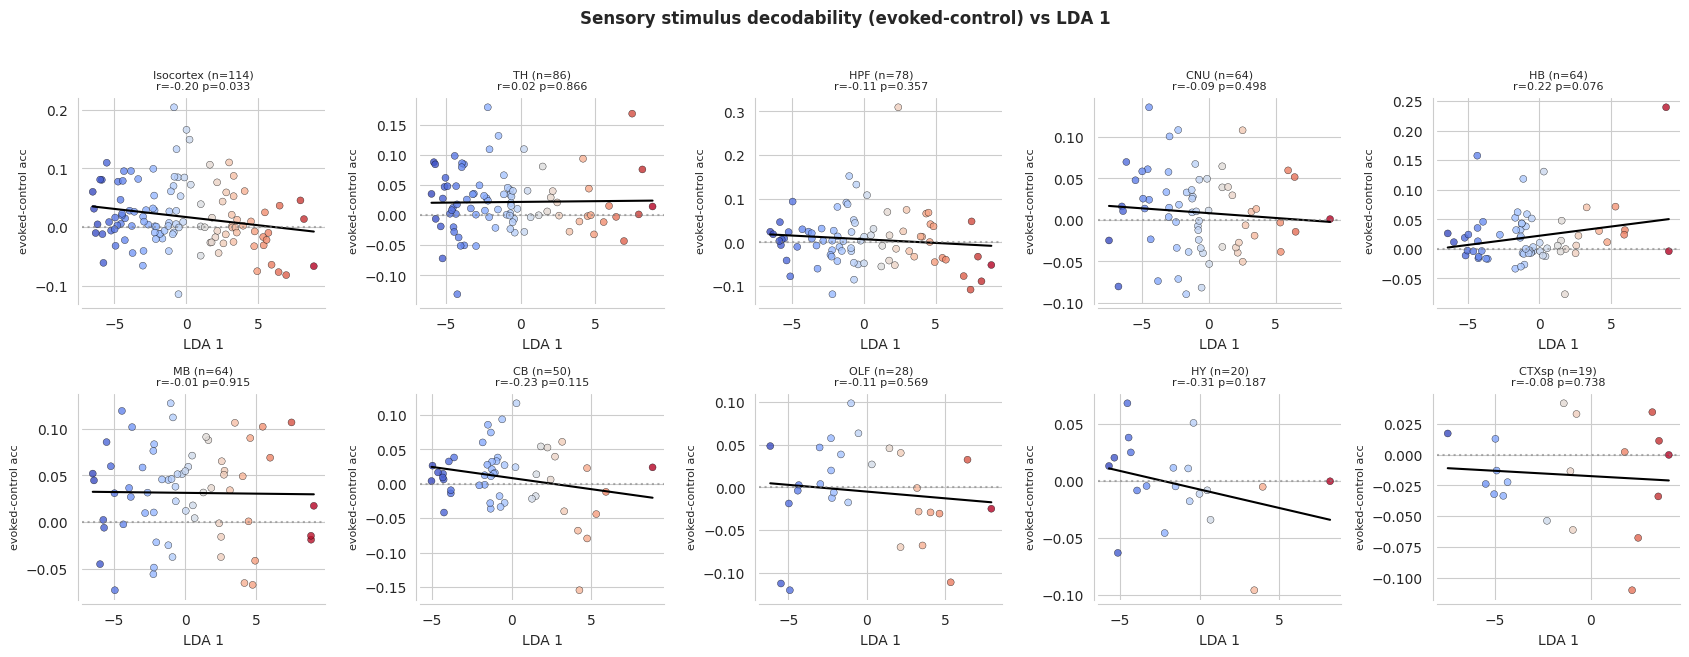

In [7]:
# scatter: sensory decodability (evoked-control) vs LDA 1, per well-sampled region
regs = sorted(well, key=lambda r: -p[p.region==r]['session'].nunique())
ncols = 5; nrows = int(np.ceil(len(regs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.4 * ncols, 3.2 * nrows), squeeze=False)
for k, reg in enumerate(regs):
    ax = axes[k // ncols][k % ncols]; g = p[p.region == reg]
    x, y = g['lda_1'].values, g['delta'].values
    r, pv = pearsonr(x, y)
    ax.scatter(x, y, c=x, cmap='coolwarm', s=25, alpha=0.8, edgecolors='k', linewidth=0.3)
    z = np.polyfit(x, y, 1); xl = np.linspace(x.min(), x.max(), 30)
    ax.plot(xl, np.polyval(z, xl), 'k-', lw=1.5)
    ax.axhline(0, color='gray', ls=':', alpha=0.6)
    ax.set_title(f'{reg} (n={len(g)})\nr={r:.2f} p={pv:.3f}', fontsize=8)
    ax.set_xlabel('LDA 1'); ax.set_ylabel('evoked-control acc', fontsize=8); sns.despine(ax=ax, offset=3)
for k in range(len(regs), nrows * ncols):
    axes[k // ncols][k % ncols].axis('off')
fig.suptitle('Sensory stimulus decodability (evoked-control) vs LDA 1', y=1.02, fontweight='bold')
plt.tight_layout(); plt.show()

## First-PC decodability vs LDA 1

In [8]:
# ===== Decodability from the FIRST PC ONLY vs LDA 1 =====
from scipy.stats import pearsonr, spearmanr
import statsmodels.formula.api as smf
lda = pd.read_pickle(prefix + 'clustering/mouse_LDA_5_bins_cut19-06-2026').rename(columns={0: 'lda_1'})

dd = pd.read_parquet(out_path)
pc1 = dd[dd['n_components'] == 1]                      # <-- first PC only
p1 = pc1.pivot_table(index=['session', 'region'], columns='window', values='accuracy').reset_index()
p1 = p1.dropna(subset=['evoked', 'control'])
p1['delta'] = p1['evoked'] - p1['control']
p1 = p1.merge(lda[['session', 'lda_1', 'mouse_name']], on='session').dropna(subset=['lda_1'])
wellp = p1.groupby('region')['session'].nunique(); wellp = wellp[wellp >= MIN_SESSIONS_CORR].index.tolist()
pp1 = p1[p1.region.isin(wellp)]
print(f"first-PC decodability: n={len(p1)} entries; well-sampled regions: {wellp}")

def pooled1(col):
    try:
        r = smf.mixedlm(f"{col} ~ lda_1 + C(region)", pp1, groups=pp1['mouse_name'],
                        vc_formula={'session': '0 + C(session)'}).fit(reml=True); m = 'mouse+session'
    except Exception:
        r = smf.mixedlm(f"{col} ~ lda_1 + C(region)", pp1, groups=pp1['session']).fit(reml=True); m = 'session'
    return r, m

for col, lab in [('evoked', 'Evoked PC1'), ('delta', 'Evoked-Control PC1 (sensory)')]:
    print(f"\n==== {lab} vs LDA 1 ====")
    for reg, g in pp1.groupby('region'):
        r, pv = pearsonr(g['lda_1'], g[col]); rho, pvv = spearmanr(g['lda_1'], g[col])
        print(f"  {reg:10s} n={len(g):3d}: r={r:+.2f} p={pv:.3f} | rho={rho:+.2f} p={pvv:.3f}")
    r, m = pooled1(col); b, se, pv = r.params['lda_1'], r.bse['lda_1'], r.pvalues['lda_1']
    print(f"  POOLED {col} ~ lda_1 + C(region) + (1|mouse) [{m}]: coef={b:+.4f} z={b/se:+.2f} p={pv:.4f}")

first-PC decodability: n=587 entries; well-sampled regions: ['CB', 'CNU', 'CTXsp', 'HB', 'HPF', 'HY', 'Isocortex', 'MB', 'OLF', 'TH']

==== Evoked PC1 vs LDA 1 ====
  CB         n= 50: r=+0.18 p=0.206 | rho=+0.19 p=0.192
  CNU        n= 64: r=-0.17 p=0.189 | rho=-0.14 p=0.264
  CTXsp      n= 19: r=+0.11 p=0.660 | rho=+0.29 p=0.232
  HB         n= 64: r=+0.02 p=0.855 | rho=+0.15 p=0.232
  HPF        n= 78: r=+0.06 p=0.597 | rho=-0.02 p=0.868
  HY         n= 20: r=-0.19 p=0.427 | rho=-0.10 p=0.679
  Isocortex  n=114: r=-0.17 p=0.079 | rho=-0.22 p=0.019
  MB         n= 64: r=+0.16 p=0.197 | rho=+0.13 p=0.291
  OLF        n= 28: r=+0.11 p=0.568 | rho=-0.01 p=0.949
  TH         n= 86: r=+0.02 p=0.861 | rho=+0.00 p=0.991
  POOLED evoked ~ lda_1 + C(region) + (1|mouse) [mouse+session]: coef=+0.0000 z=+0.03 p=0.9776

==== Evoked-Control PC1 (sensory) vs LDA 1 ====
  CB         n= 50: r=-0.12 p=0.413 | rho=-0.14 p=0.344
  CNU        n= 64: r=-0.29 p=0.020 | rho=-0.26 p=0.036
  CTXsp      n= 19:

/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


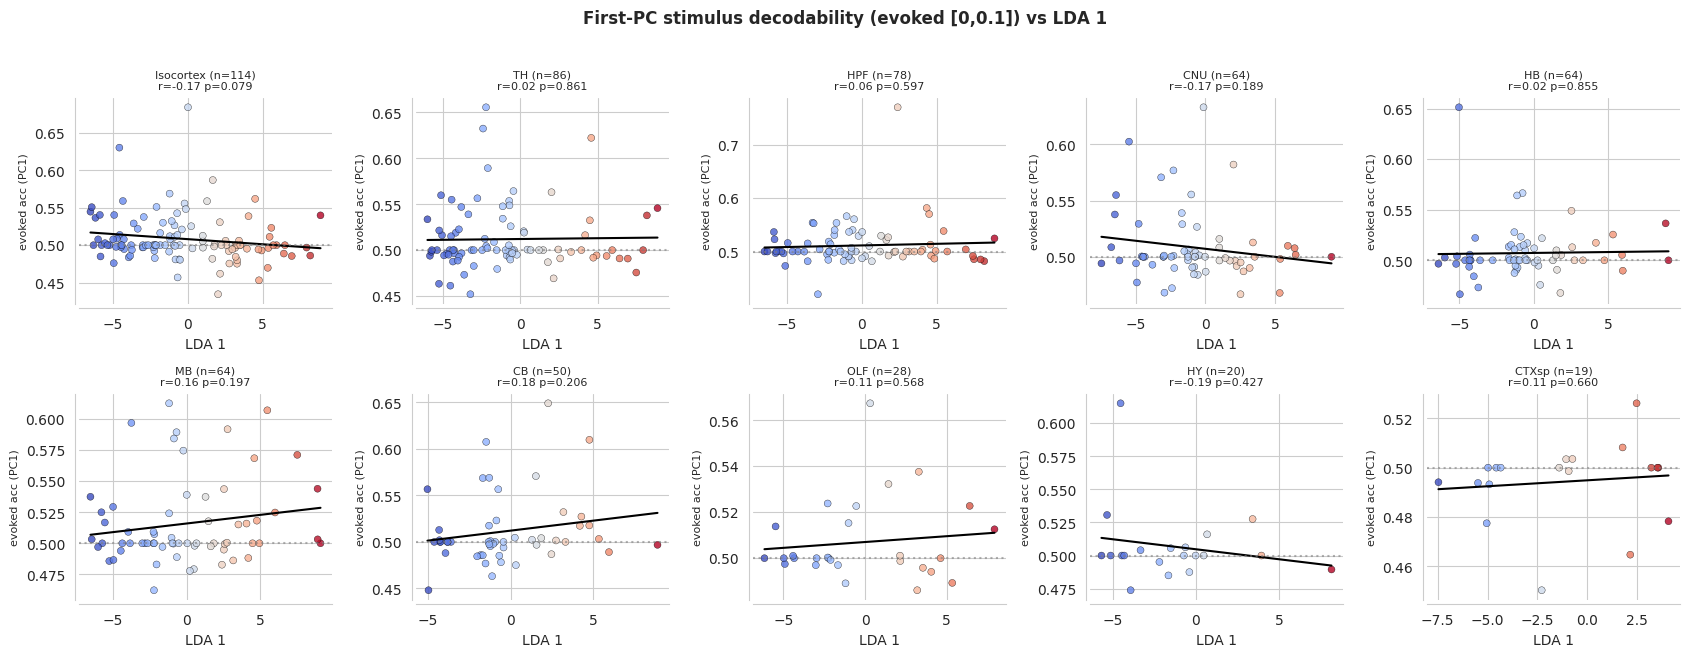

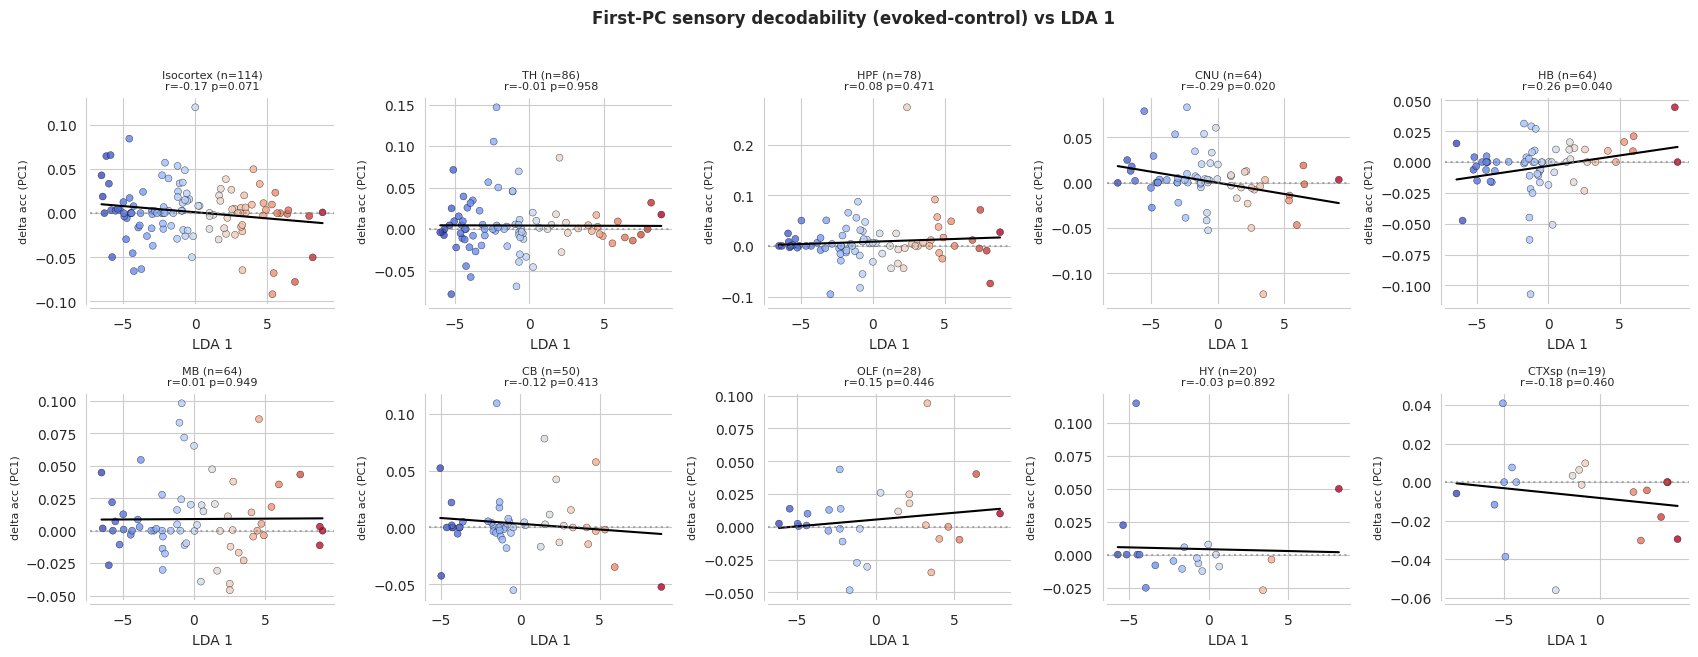

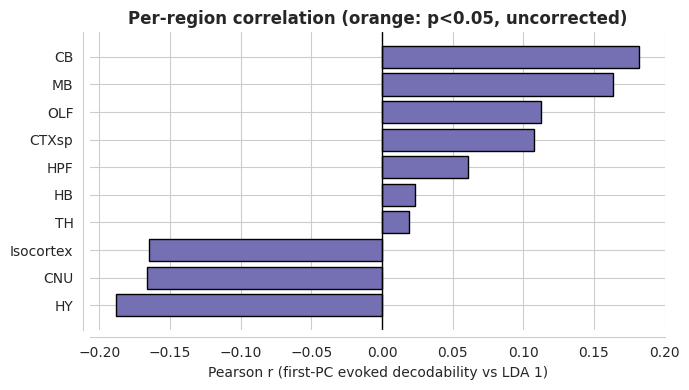

In [9]:
# scatter grids: first-PC decodability (evoked, and sensory) vs LDA 1
for col, ttl in [('evoked', 'First-PC stimulus decodability (evoked [0,0.1]) vs LDA 1'),
                 ('delta', 'First-PC sensory decodability (evoked-control) vs LDA 1')]:
    regs = sorted(wellp, key=lambda r: -pp1[pp1.region == r]['session'].nunique())
    ncols = 5; nrows = int(np.ceil(len(regs) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.4 * ncols, 3.2 * nrows), squeeze=False)
    for k, reg in enumerate(regs):
        ax = axes[k // ncols][k % ncols]; g = pp1[pp1.region == reg]
        x, y = g['lda_1'].values, g[col].values
        r, pv = pearsonr(x, y)
        ax.scatter(x, y, c=x, cmap='coolwarm', s=25, alpha=0.8, edgecolors='k', linewidth=0.3)
        z = np.polyfit(x, y, 1); xl = np.linspace(x.min(), x.max(), 30)
        ax.plot(xl, np.polyval(z, xl), 'k-', lw=1.5)
        if col == 'delta': ax.axhline(0, color='gray', ls=':', alpha=0.6)
        else: ax.axhline(0.5, color='gray', ls=':', alpha=0.6)
        ax.set_title(f'{reg} (n={len(g)})\nr={r:.2f} p={pv:.3f}', fontsize=8)
        ax.set_xlabel('LDA 1'); ax.set_ylabel(f'{col} acc (PC1)', fontsize=8); sns.despine(ax=ax, offset=3)
    for k in range(len(regs), nrows * ncols):
        axes[k // ncols][k % ncols].axis('off')
    fig.suptitle(ttl, y=1.02, fontweight='bold')
    plt.tight_layout(); plt.show()

# summary: pooled per-region Pearson r (evoked PC1 vs LDA1) as a bar
rs = [(reg, pearsonr(g['lda_1'], g['evoked'])[0], pearsonr(g['lda_1'], g['evoked'])[1])
      for reg, g in pp1.groupby('region')]
rs = sorted(rs, key=lambda t: t[1])
fig, ax = plt.subplots(figsize=(7, 4))
cols = ['#d95f02' if pv < 0.05 else '#7570b3' for _, _, pv in rs]
ax.barh([t[0] for t in rs], [t[1] for t in rs], color=cols, edgecolor='black')
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Pearson r (first-PC evoked decodability vs LDA 1)')
ax.set_title('Per-region correlation (orange: p<0.05, uncorrected)', fontweight='bold')
sns.despine(ax=ax, offset=5); plt.tight_layout(); plt.show()

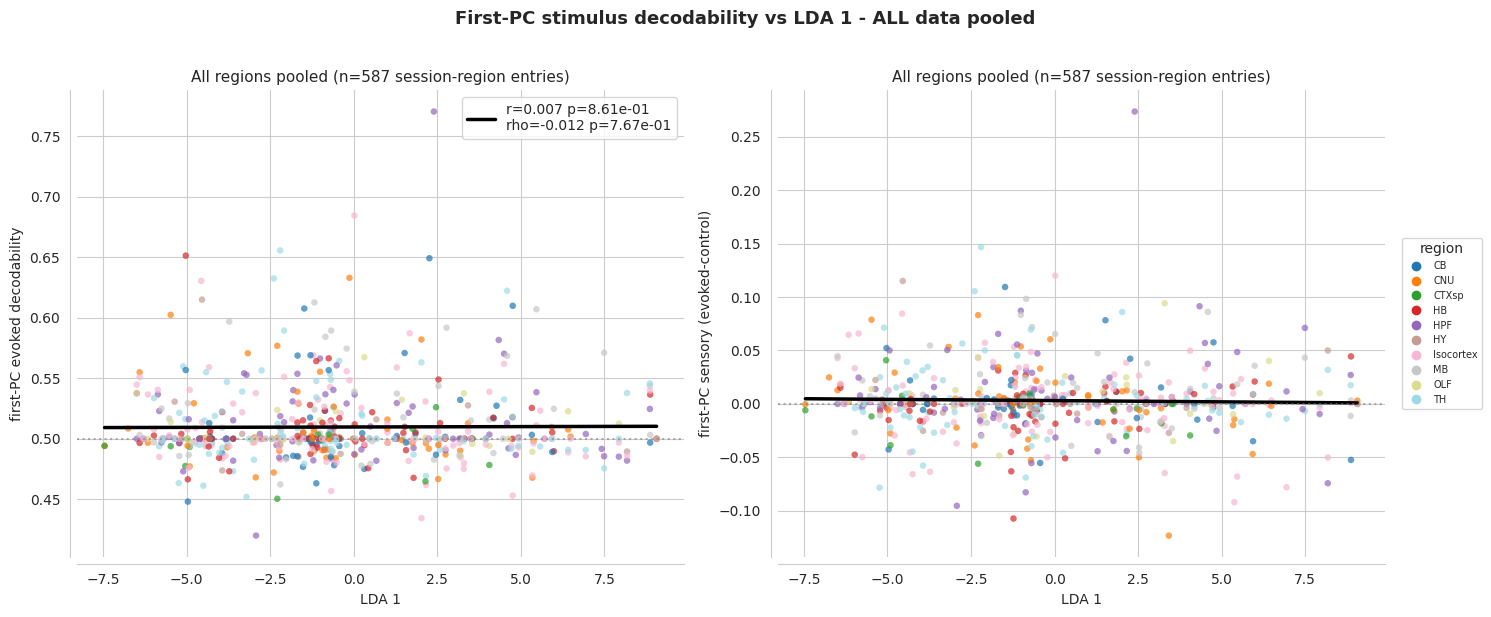

All-data pooled (n=587):
  evoked : pearson r=+0.007 p=8.607e-01 | spearman rho=-0.012 p=7.675e-01
  delta  : pearson r=-0.027 p=5.089e-01 | spearman rho=-0.032 p=4.461e-01
(raw pooling ignores region baselines; region-controlled mixed model above is the proper test)


In [10]:
# ===== ALL data together (all regions pooled), first-PC decodability vs LDA 1 =====
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
region_list = sorted(p1['region'].unique())
palette = dict(zip(region_list, plt.cm.tab20(np.linspace(0, 1, len(region_list)))))
for ax, col, ylab in [(axes[0], 'evoked', 'first-PC evoked decodability'),
                      (axes[1], 'delta', 'first-PC sensory (evoked-control)')]:
    x = p1['lda_1'].values; y = p1[col].values
    r, pv = pearsonr(x, y); rho, pvv = spearmanr(x, y)
    ax.scatter(x, y, c=[palette[rr] for rr in p1['region']], s=22, alpha=0.7, edgecolors='none')
    z = np.polyfit(x, y, 1); xl = np.linspace(x.min(), x.max(), 100)
    ax.plot(xl, np.polyval(z, xl), 'k-', lw=2.5, label=f'r={r:.3f} p={pv:.2e}\nrho={rho:.3f} p={pvv:.2e}')
    ax.axhline(0.5 if col == 'evoked' else 0.0, color='gray', ls=':', alpha=0.6)
    ax.set_xlabel('LDA 1'); ax.set_ylabel(ylab)
    ax.set_title(f'All regions pooled (n={len(p1)} session-region entries)', fontsize=11)
    ax.legend(fontsize=10, loc='best'); sns.despine(ax=ax, offset=5)
handles = [plt.Line2D([0], [0], marker='o', ls='', color=palette[rr], label=rr) for rr in region_list]
axes[1].legend(handles=handles, fontsize=7, loc='center left', bbox_to_anchor=(1.02, 0.5), title='region')
fig.suptitle('First-PC stimulus decodability vs LDA 1 - ALL data pooled', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"All-data pooled (n={len(p1)}):")
for col in ['evoked', 'delta']:
    r, pv = pearsonr(p1['lda_1'], p1[col]); rho, pvv = spearmanr(p1['lda_1'], p1[col])
    print(f"  {col:7s}: pearson r={r:+.3f} p={pv:.3e} | spearman rho={rho:+.3f} p={pvv:.3e}")
print("(raw pooling ignores region baselines; region-controlled mixed model above is the proper test)")